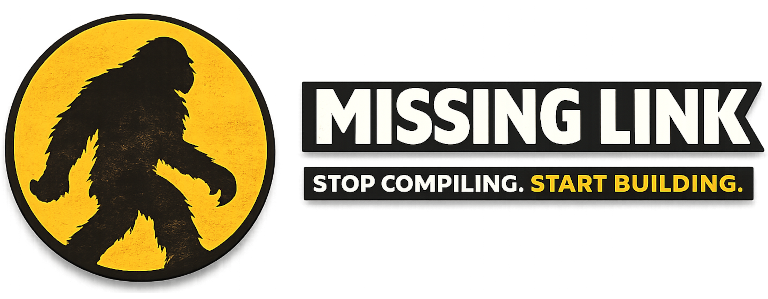

The *TRELLIS.2 MissingLink Notebook* lets you **Generate 3D Models from Images** using the latest state of the art model from Microsoft.

It is designed to get you up and running in colab with zero configuration and zero headaches so you don't waste time and money on your A100 compiling and optimizing dependencies.

1. [Get a Token](https://www.missinglink.build/pricing.html) by signing up for the free trial or purchase a bundle at https://www.missinglink.build this will let you download the optimized A100 Colab wheels. **Replace the ****** text with your token in the cell below.** ( see [Additional Purchase Options](https://www.missinglink.build/pricing.html)

2. **Connect to L4 or A100 Runtime ( Top Right of Colab UI )** you will need to buy credits to run these instances [Buy Colab Credits](https://colab.research.google.com/signup?utm_source=resource_tab&utm_medium=link&utm_campaign=payg_learn_more)

3. Click '**Run All**'

4. It may take ~2-5min to downloand and install the missinglink wheels and trellis models, once the cell is done it should launch the UI. You can click on link that appears in the cell output to launch it in a seperate tab.

Inside the UI you will be able to generate 3D models from images in batch, to produce models at the fastest rate and best utilize your A100 time it is recommended that you prepare the images you plan to generate models from ahead of time.

*Tip: If you get disconnected restart your runtime to clear memory, you may need to run cell 1 again to set your MISSING_LINK_TOKEN*

*Don't waste your time worrying about configuration or waiting for compilation!*

In [1]:
#Cell 1 - REPLACE ****** WITH REAL TOKEN
#1. Get a token and install MissingLink dependencies

import os
MACHINE='t4' # Change to l4 if on L4
os.environ['MISSING_LINK_TOKEN']="ml_Leg4smQpIidX0JWPfKXKq6Maht7fvAhQ"

#0. You should connect to drive to save your models
if not os.path.exists("/content/drive/MyDrive"):
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

TOKEN=os.environ['MISSING_LINK_TOKEN']
!pip install --no-deps -r "https://{TOKEN}@missinglink.build/{MACHINE}.txt"
!pip install -q trimesh pygltflib plyfile moderngl huggingface_hub kornia kornia-rs huggingface_hub
if not os.path.exists("/content/TRELLIS.2"):
  !git clone --recursive https://github.com/PotentiallyARobot/TRELLIS.2.git
if not os.path.exists("/content/MissingLink-Extras"):
  !git clone https://github.com/PotentiallyARobot/MissingLink-Extras.git


# For faster downloads if you have huggingface
#from huggingface_hub import login
#HF_TOKEN="***************************"
#os.environ["HF_TOKEN"]=HF_TOKEN
#login(token=HF_TOKEN, add_to_git_credential=False)  # will prompt for your token (input is hidden)

#3. Upload your image files with transparency! (This will save time on A100!)
import os
os.makedirs("/content/images_in", exist_ok=True)

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 73.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 114.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.4/412.4 MB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 75.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 115.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 67.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.1/92.1 kB 391.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.8/740.8 kB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.4/296.4 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 125.7 MB/s eta 0:00:00
   ━━━━━━━━━

The code below will launch the Trellis.2 User Interface by MissingLink at a generated URL. Make sure you have run the previous cell and set your MISSING_LINK_TOKEN before running, startup takes 2-5min depending on download speeds.

In [ ]:
import os
os.chdir("/content/MissingLink-Extras/model-generation-studio")

from backend import *
exec(open("launch_colab.py").read())

Fetching 22 files:   0%|          | 0/22 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

Utility function for colab, keep alive thread will keep the notebook alive during generation ( RUN IT AFTER LAUNCHING UI )

In [ ]:
import sys
sys.path.append("/content/MissingLink-Extras/")
from keep_alive import run_keep_alive
run_keep_alive()

(Optional) If you don't care for a UI and want to process images faster, you can use the batch process

In [ ]:

#import sys
#sys.path.append("/content/TRELLIS.2/")

# # ── Max quality (default) ──
# UNCOMMENT TO RUN
#from missinglink.trellis2_batch_process import run_trellis2_batch
#results = run_trellis2_batch(
#    input_dir="/content/images_in",
#    output_dir="/content/drive/MyDrive/trellis_batch_output",
#    upload_images=True,
#    model_name="microsoft/TRELLIS.2-4B",
#    low_vram=True,
#    hdri_path=None,                   # uses bundled forest.exr
#    ss_steps=12,
#    shape_steps=12,
#    tex_steps=12,
#    texture_size=4096,
#    decimate_target=1_000_000,
#    remesh=True,
#    remesh_band=1.0,
#    render_mode="snapshot",           # "video" | "snapshot" | "none"
#    video_resolution=512,
#    video_num_frames=120,
#    video_fps=15,
#    render_max_faces=16_000_000,
#    max_retries=3,
#    retry_delay=2.0,
#    skip_already_done=True,
#    verbose=True,
#)